#Problem Statement

Given data about COVID-19 patients, write code to visualize the impact and
analyze the trend of rate of infection and recovery as well as make predictions
about the number of cases expected a week in future based on the current
trends.

#Project Objective
1. Anlyse the Covid-19 international data (Merge different data files as one frame).
2. Build time series model (using prophet api), and visualize the predictions.

# Data Discription

CSV and Excel files containing data about the number of COVID-19 confirmed
deaths and recovered patients both around the world and in India.

1. Province/State - Province name of the country
2. Country/Region - Country name
3. Lat - Lattitude of the place
4. Long - Longtitude of the place
5. Date - Date of covid status record
6. Confirmed - Count of covid possitive patient
7. Deaths - count of deaths
8. Recovered - count of recovered people.
9. Active - count of current active patient.
10. WHO Region - WHO Region where the country/region comes under.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as ex


In [ ]:
!pip install prophet

In [ ]:
# import file. No multiple files , seems merged already.
df = pd.read_csv('covid_19_clean_complete.csv')

#4. Data Pre-processing Steps and Inspiration
1. ensure duplicates and null values handled in  dataset
2. process require encoding and scaling with dataset.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df.describe().round(0)

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.0,49068.0,49068.0,49068.0,49068.0,49068.0
mean,21.0,24.0,16885.0,884.0,7916.0,8085.0
std,25.0,70.0,127300.0,6314.0,54801.0,76259.0
min,-52.0,-135.0,0.0,0.0,0.0,-14.0
25%,8.0,-15.0,4.0,0.0,0.0,0.0
50%,24.0,22.0,168.0,2.0,29.0,26.0
75%,41.0,81.0,1518.0,30.0,666.0,606.0
max,72.0,178.0,4290259.0,148011.0,1846641.0,2816444.0


In [ ]:
pd.concat([df.head(10),df.tail(10)])

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.060800,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.416100,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.069100,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.473500,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.868800,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [ ]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
# pd.options.display.max_rows = 300

In [ ]:
# The countries having province/state
df.groupby(by=['Country/Region','Province/State'], dropna=False)\
 [['Country/Region','Province/State']].count()

,,Country/Region,Province/State
Country/Region,Province/State,,
Afghanistan,NaN,188,0
Albania,NaN,188,0
Algeria,NaN,188,0
Andorra,NaN,188,0
Angola,NaN,188,0
...,...,...,...
West Bank and Gaza,NaN,188,0
Western Sahara,NaN,188,0
Yemen,NaN,188,0


In [ ]:
df[df['Country/Region']=='India'].isna().sum()

,0
Province/State,188
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.sample(20)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
4381,NaN,Taiwan*,23.700000,121.000000,2020-02-07,16,0,1,15,Western Pacific
33167,NaN,Bangladesh,23.685000,90.356300,2020-05-28,40321,559,8425,31337,South-East Asia
2040,NaN,Ukraine,48.379400,31.165600,2020-01-29,0,0,0,0,Europe
25656,Xinjiang,China,41.112900,85.240100,2020-04-29,76,3,73,0,Western Pacific
28793,NaN,Congo (Kinshasa),-4.038300,21.758700,2020-05-11,1024,41,141,842,Africa
27501,NaN,Egypt,26.820553,30.802498,2020-05-06,7588,469,1815,5304,Eastern Mediterranean
26402,Ontario,Canada,51.253800,-85.323200,2020-05-02,18321,1292,0,17029,Americas
25088,NaN,Cabo Verde,16.538800,-23.041800,2020-04-27,109,1,1,107,Africa
48751,NaN,Taiwan*,23.700000,121.000000,2020-07-26,458,7,440,11,Western Pacific
23358,NaN,India,20.593684,78.962880,2020-04-20,18539,592,3273,14674,South-East Asia


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [ ]:
dfg_tot = df.groupby(by=df['Date'].dt.to_period('M'))[['Active', 'Confirmed', 'Deaths']].sum()
dfg_tot

,Active,Confirmed,Deaths
Date,,,
2020-01,36807,38534,889
2020-02,1252893,1663437,46875
2020-03,5960842,9002815,397601
2020-04,43136428,63391662,4311214
2020-05,82503957,144990399,9609604
2020-06,116232466,246525787,13309053
2020-07,147591957,362895848,15709667


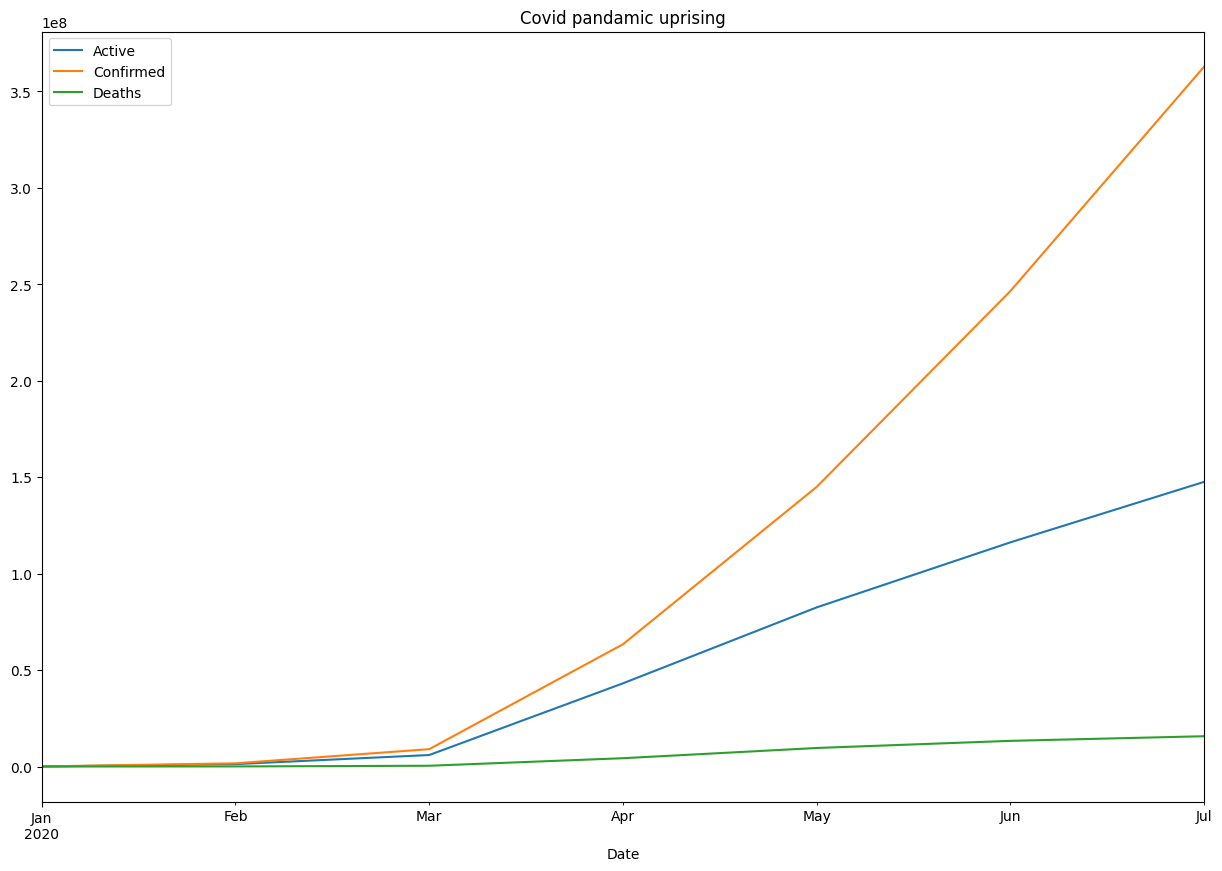

In [ ]:
dfg_tot.plot(figsize=(15,10), kind='line')
plt.title('Covid pandamic uprising')
plt.show()

<Axes: title={'center': 'Monthly Global Covid Cases'}, xlabel='Date'>

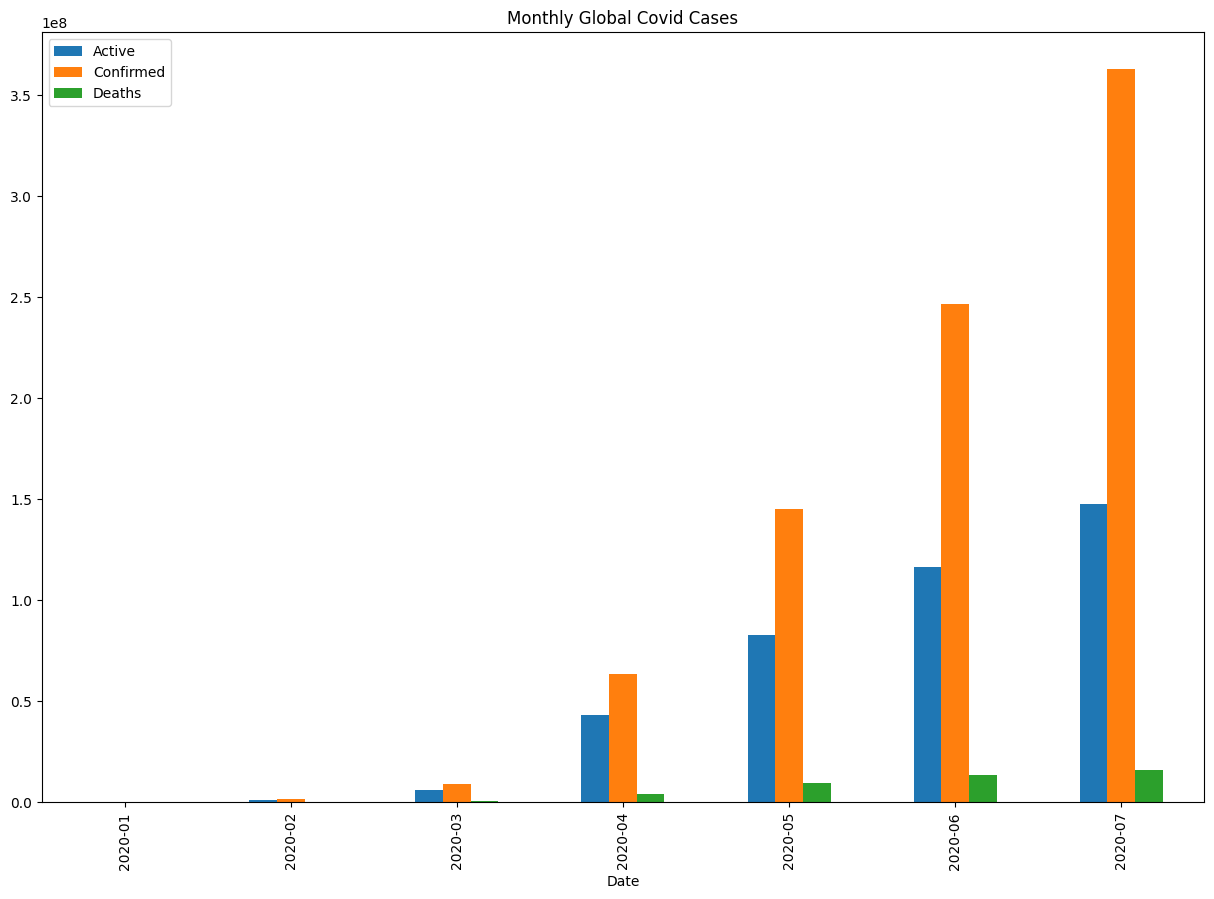

In [ ]:
dfg_tot.plot(kind='bar', figsize=(15,10), title='Monthly Global Covid Cases')

In [ ]:
df[df['Country/Region']=='India'].tail(20)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
43977,NaN,India,20.593684,78.96288,2020-07-08,767296,21129,476378,269789,South-East Asia
44238,NaN,India,20.593684,78.96288,2020-07-09,793802,21604,495513,276685,South-East Asia
44499,NaN,India,20.593684,78.96288,2020-07-10,820916,22123,515386,283407,South-East Asia
44760,NaN,India,20.593684,78.96288,2020-07-11,849522,22673,534618,292231,South-East Asia
45021,NaN,India,20.593684,78.96288,2020-07-12,878254,23174,553471,301609,South-East Asia
45282,NaN,India,20.593684,78.96288,2020-07-13,906752,23727,571460,311565,South-East Asia
45543,NaN,India,20.593684,78.96288,2020-07-14,936181,24309,592032,319840,South-East Asia
45804,NaN,India,20.593684,78.96288,2020-07-15,968857,24914,612768,331175,South-East Asia
46065,NaN,India,20.593684,78.96288,2020-07-16,1003832,25602,635757,342473,South-East Asia
46326,NaN,India,20.593684,78.96288,2020-07-17,1039084,26273,653751,359060,South-East Asia


#Choosing the Algorithm for the Project
Time Series models SARIMA/Prophet are suitable for this project since the objective is to predict cases for future 7 days.

Prophet choosed as simple and recommended.

In [ ]:
df_global = df.groupby(by=df['Date'])[
    ['Confirmed', 'Deaths','Recovered', 'Active']].sum()
df_global = df_global.reset_index()
df_global_md = df_global.rename(
    columns={'Date': 'ds', 'Confirmed': 'y'})[['ds','y']]


In [ ]:
df_global_md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      188 non-null    datetime64[ns]
 1   y       188 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.1 KB


In [ ]:
!pip install prophet

In [ ]:
import prophet

In [ ]:
model = prophet.Prophet()

In [ ]:
model.fit(df_global_md)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk6d6qsmi/zash86_6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk6d6qsmi/jsajjz81.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95307', 'data', 'file=/tmp/tmpk6d6qsmi/zash86_6.json', 'init=/tmp/tmpk6d6qsmi/jsajjz81.json', 'output', 'file=/tmp/tmpk6d6qsmi/prophet_model4ffmhf25/prophet_model-20250902114216.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:42:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:42:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
df_future = model.make_future_dataframe(periods=7)

In [ ]:
df['Date'].tail(1)

,Date
49067,2020-07-27


In [ ]:
df_future.tail(7)

,ds
188,2020-07-28
189,2020-07-29
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02
194,2020-08-03


In [ ]:
forecast = model.predict(df_future)

In [ ]:
forecast.tail(7)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
188,2020-07-28,1.633705e+07,1.621844e+07,1.643357e+07,1.633705e+07,1.633705e+07,-16846.245488,-16846.245488,-16846.245488,-16846.245488,-16846.245488,-16846.245488,0.0,0.0,0.0,1.632020e+07
189,2020-07-29,1.654104e+07,1.642083e+07,1.664335e+07,1.653966e+07,1.654159e+07,-11063.561776,-11063.561776,-11063.561776,-11063.561776,-11063.561776,-11063.561776,0.0,0.0,0.0,1.652997e+07
190,2020-07-30,1.674503e+07,1.663353e+07,1.684585e+07,1.674000e+07,1.674902e+07,-1117.543336,-1117.543336,-1117.543336,-1117.543336,-1117.543336,-1117.543336,0.0,0.0,0.0,1.674391e+07
191,2020-07-31,1.694902e+07,1.684326e+07,1.706898e+07,1.693786e+07,1.695834e+07,10080.982351,10080.982351,10080.982351,10080.982351,10080.982351,10080.982351,0.0,0.0,0.0,1.695910e+07
192,2020-08-01,1.715301e+07,1.705566e+07,1.727895e+07,1.713386e+07,1.717031e+07,13750.330594,13750.330594,13750.330594,13750.330594,13750.330594,13750.330594,0.0,0.0,0.0,1.716676e+07
193,2020-08-02,1.735700e+07,1.725028e+07,1.747762e+07,1.732712e+07,1.738192e+07,7298.794381,7298.794381,7298.794381,7298.794381,7298.794381,7298.794381,0.0,0.0,0.0,1.736430e+07
194,2020-08-03,1.756099e+07,1.744741e+07,1.767425e+07,1.752179e+07,1.759298e+07,-2102.756726,-2102.756726,-2102.756726,-2102.756726,-2102.756726,-2102.756726,0.0,0.0,0.0,1.755889e+07


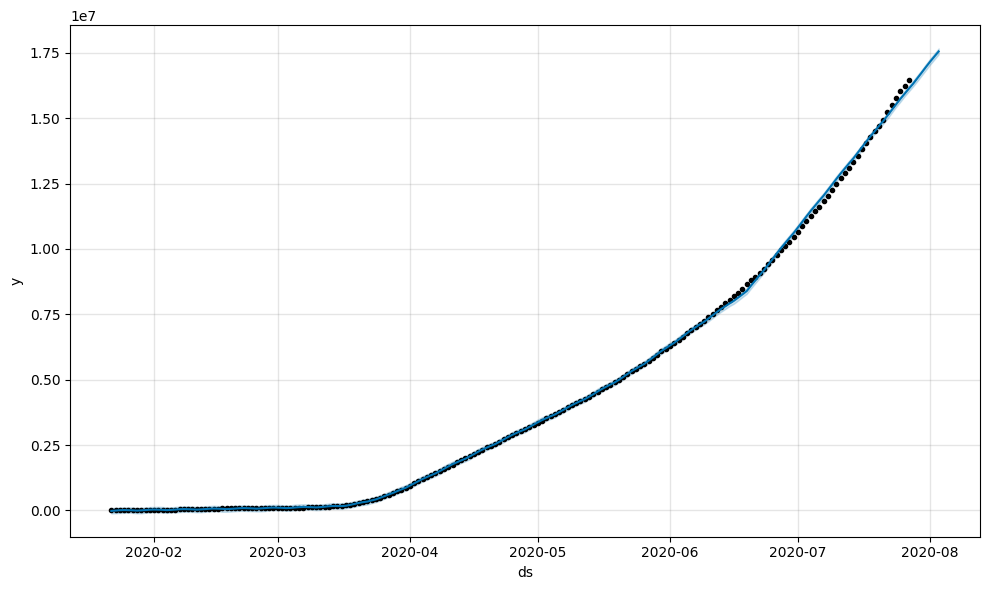

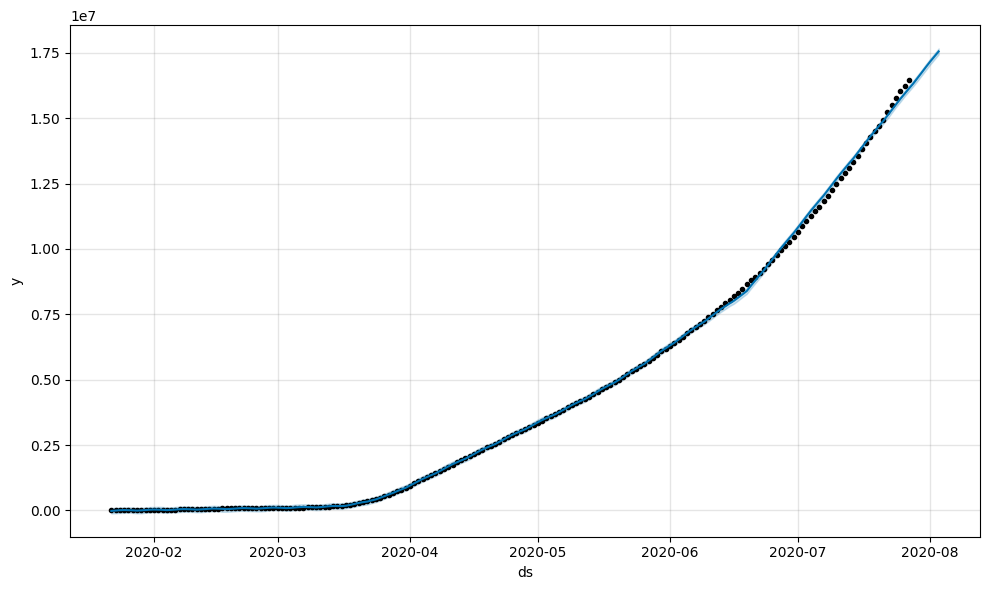

In [ ]:
model.plot(forecast)

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

In [ ]:
plot_plotly(model, forecast)

In [ ]:
plot_components_plotly(model, forecast)

#Conclusion
Forecast has been done for the next 7 days for confirmed case, data clearly indicates upward trending and significant increases in the patients globaly and model predicts the same.